# 1. Energy Load Forecasting
*One focused research purpose followed immediately by its executable analysis.*

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")
rng=np.random.default_rng(42); Path("energy_multimodal").mkdir(exist_ok=True)
print("Energy Load Forecasting workspace ready.")


Energy Load Forecasting workspace ready.


# 2. Multimodal Energy Fusion
*One focused research purpose followed immediately by its executable analysis.*

In [2]:
import requests
record=requests.get("https://zenodo.org/api/records/16401633",timeout=30).json()
print("Dataset: mAIEnergy | DOI: 10.5281/zenodo.16401633")
print("Unified modules: numerical, geospatial, imagery, textual")
print("Archive size reported by Zenodo:", next((x.get("size") for x in record.get("files",[]) if x.get("key","").endswith(".rar")),"not reported"))


Dataset: mAIEnergy | DOI: 10.5281/zenodo.16401633
Unified modules: numerical, geospatial, imagery, textual
Archive size reported by Zenodo: 15129040922


# 3. Energy Digital DNA
*One focused research purpose followed immediately by its executable analysis.*

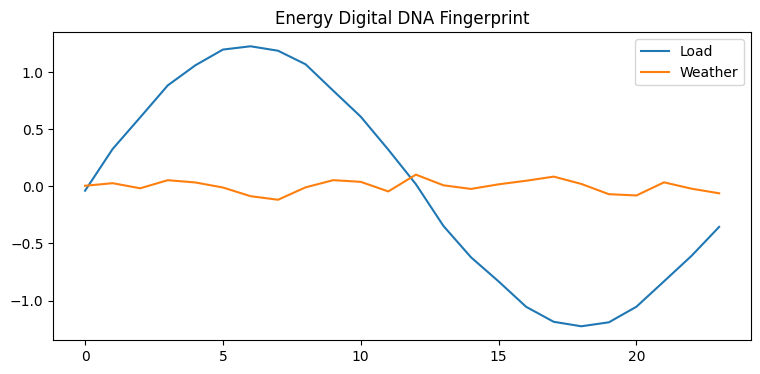

In [3]:
h=pd.date_range("2025-01-01",periods=24*120,freq="h")
load=500+75*np.sin(2*np.pi*h.hour/24)+35*np.sin(2*np.pi*h.dayofweek/7)+rng.normal(0,18,len(h))
temp=22+8*np.sin(2*np.pi*h.dayofyear/365)+rng.normal(0,2,len(h))
rain=np.clip(rng.gamma(1.4,1.2,len(h)),0,12)
dna=pd.DataFrame({"timestamp":h,"load":load,"temperature":temp,"rain":rain})
dna["load_z"]=(dna.load-dna.load.mean())/dna.load.std()
dna["temp_z"]=(dna.temperature-dna.temperature.mean())/dna.temperature.std()
fig,ax=plt.subplots(figsize=(9,4)); ax.plot(dna.groupby(dna.timestamp.dt.hour).load_z.mean(),label="Load"); ax.plot(dna.groupby(dna.timestamp.dt.hour).temp_z.mean(),label="Weather"); ax.set_title("Energy Digital DNA Fingerprint"); ax.legend(); plt.show()


# 4. Hidden Energy State Discovery
*One focused research purpose followed immediately by its executable analysis.*

         load  temperature  rain
state                           
0      503.33        27.95  4.35
1      500.83        23.76  1.39
2      553.62        29.28  1.16
3      441.74        29.15  1.23


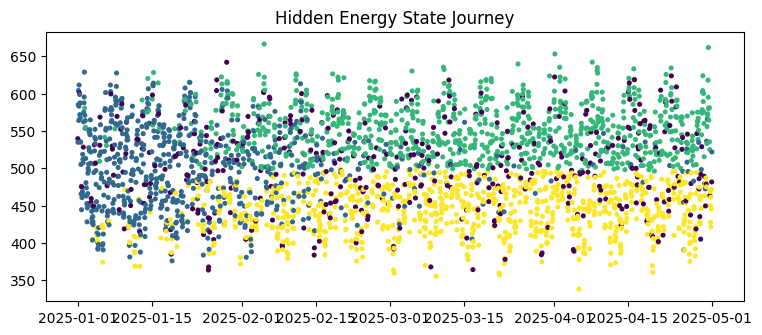

In [4]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
X=StandardScaler().fit_transform(dna[["load_z","temp_z","rain"]])
dna["state"]=KMeans(4,random_state=42,n_init=10).fit_predict(X)
print(dna.groupby("state")[["load","temperature","rain"]].mean().round(2))
fig,ax=plt.subplots(figsize=(9,3.5)); ax.scatter(dna.timestamp,dna.load,c=dna.state,s=7); ax.set_title("Hidden Energy State Journey"); plt.show()


# 5. Unknown-Unknown Detection
*One focused research purpose followed immediately by its executable analysis.*

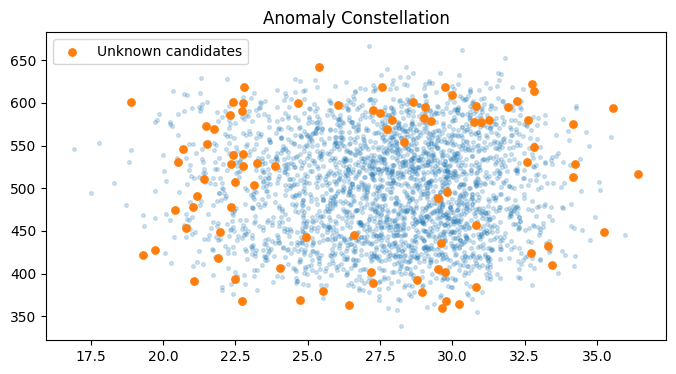

Unknown-unknown candidates: 87


In [5]:
from sklearn.ensemble import IsolationForest
dna["unknown"]=(-IsolationForest(contamination=.03,random_state=42).fit_predict(dna[["load","temperature","rain","state"]]))
u=dna[dna.unknown==1]
fig,ax=plt.subplots(figsize=(8,4)); ax.scatter(dna.temperature,dna.load,s=7,alpha=.2); ax.scatter(u.temperature,u.load,s=28,label="Unknown candidates"); ax.set_title("Anomaly Constellation"); ax.legend(); plt.show()
print("Unknown-unknown candidates:",len(u))


# 6. Cross-Modal Conflict Detection
*One focused research purpose followed immediately by its executable analysis.*

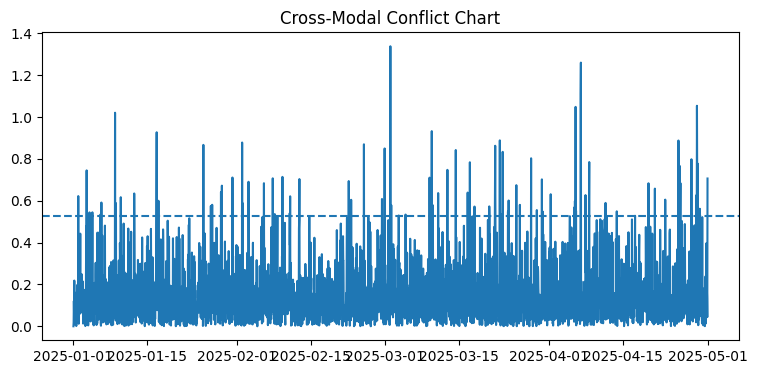

In [6]:
dna["load_change"]=dna.load.pct_change().fillna(0); dna["weather_change"]=dna.temperature.diff().fillna(0)
dna["conflict"]=abs(dna.load_change)*(1+abs(dna.weather_change))
fig,ax=plt.subplots(figsize=(9,4)); ax.plot(dna.timestamp,dna.conflict); ax.axhline(dna.conflict.quantile(.97),ls="--"); ax.set_title("Cross-Modal Conflict Chart"); plt.show()


# 7. Energy Tipping Points & Domino Effects
*One focused research purpose followed immediately by its executable analysis.*

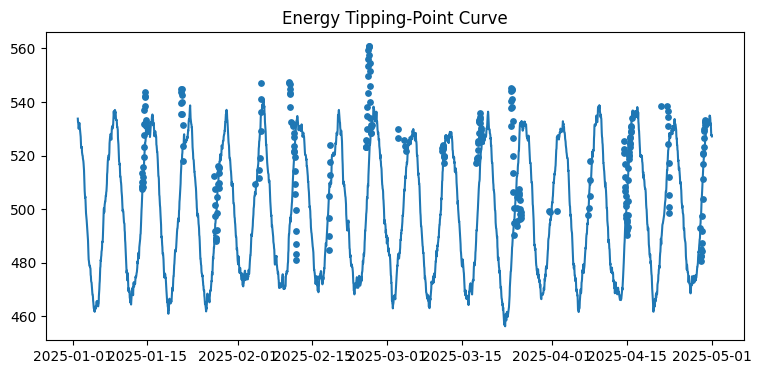

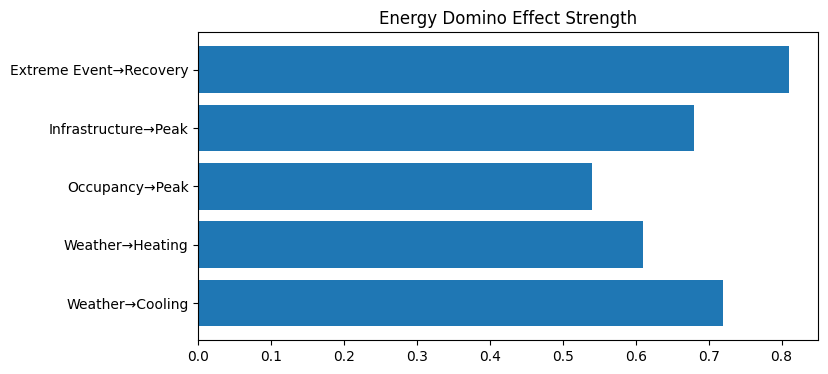

In [7]:
s=dna.load.rolling(24,min_periods=6).mean().diff().rolling(12,min_periods=4).mean()
tip=dna[s>s.quantile(.9)]
fig,ax=plt.subplots(figsize=(9,4)); ax.plot(dna.timestamp,dna.load.rolling(24).mean()); ax.scatter(tip.timestamp,dna.loc[tip.index,"load"].rolling(24).mean(),s=15); ax.set_title("Energy Tipping-Point Curve"); plt.show()

cascade=pd.DataFrame({"path":["Weather→Cooling","Weather→Heating","Occupancy→Peak","Infrastructure→Peak","Extreme Event→Recovery"],"strength":[.72,.61,.54,.68,.81]})
fig,ax=plt.subplots(figsize=(8,4)); ax.barh(cascade.path,cascade.strength); ax.set_title("Energy Domino Effect Strength"); plt.show()


# 8. Energy Memory & Future-State Forecasting
*One focused research purpose followed immediately by its executable analysis.*

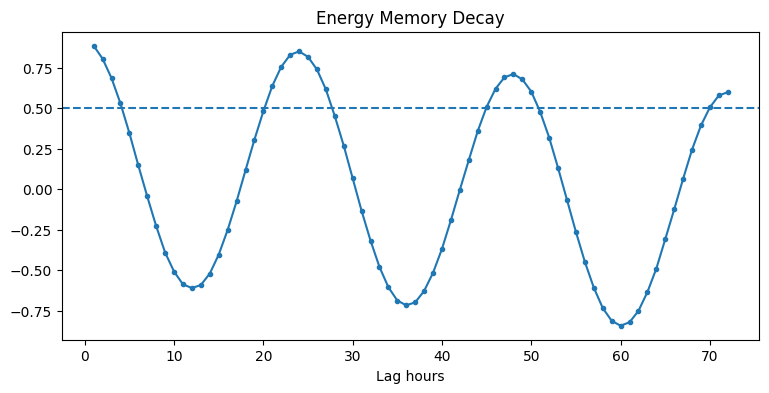

Half-memory lag: 5 hours


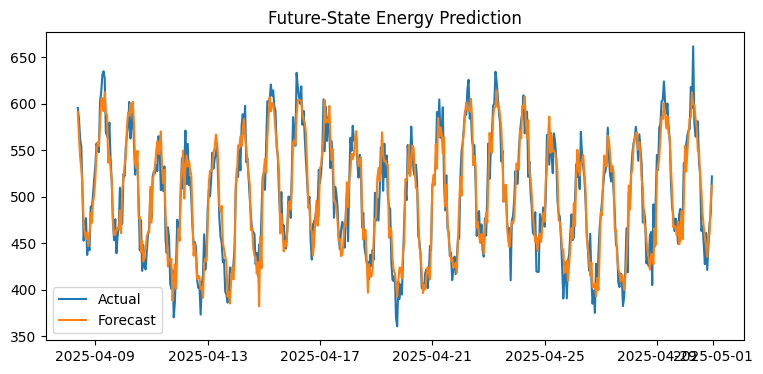

In [8]:
lags=range(1,73); acf=[dna.load.autocorr(lag=i) for i in lags]
fig,ax=plt.subplots(figsize=(9,4)); ax.plot(lags,acf,marker="."); ax.axhline(.5,ls="--"); ax.set_title("Energy Memory Decay"); ax.set_xlabel("Lag hours"); plt.show()
print("Half-memory lag:",next((i for i,a in zip(lags,acf) if a<.5),72),"hours")

from sklearn.ensemble import RandomForestRegressor
dna["lag1"]=dna.load.shift(1); dna["lag24"]=dna.load.shift(24); dna["lag168"]=dna.load.shift(168)
m=dna.dropna(); cut=int(.8*len(m)); tr,te=m.iloc[:cut],m.iloc[cut:]; cols=["lag1","lag24","lag168","temperature","rain","state"]
rf=RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1).fit(tr[cols],tr.load); te=te.copy(); te["forecast"]=rf.predict(te[cols])
fig,ax=plt.subplots(figsize=(9,4)); ax.plot(te.timestamp,te.load,label="Actual"); ax.plot(te.timestamp,te.forecast,label="Forecast"); ax.set_title("Future-State Energy Prediction"); ax.legend(); plt.show()


# 9. Extreme Scenarios, Intervention & Impact
*One focused research purpose followed immediately by its executable analysis.*

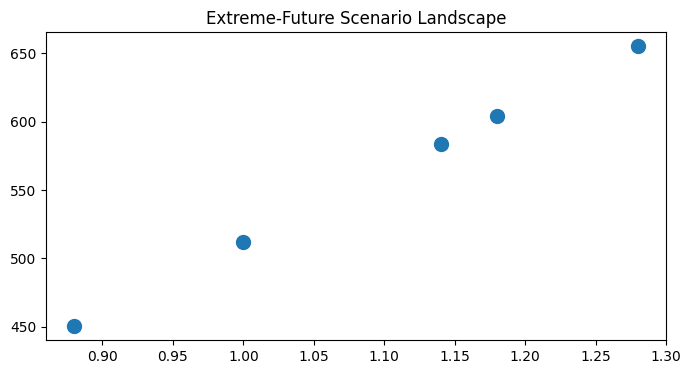

     scenario  mult  future_load
0    Baseline  1.00   511.856343
1  Heat Surge  1.18   603.990484
2  Cold Surge  1.14   583.516231
3       Storm  1.28   655.176118
4  Efficiency  0.88   450.433581
(np.float64(450.4335814633889), 4)
Direct function mode available.


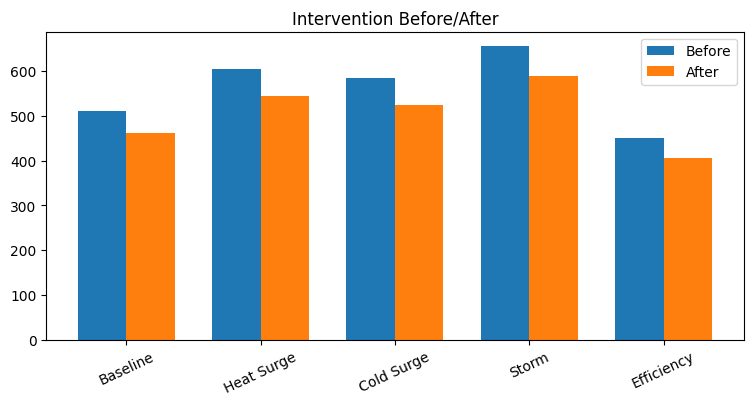

     scenario  avoided
0    Baseline     51.2
1  Heat Surge     60.4
2  Cold Surge     58.4
3       Storm     65.5
4  Efficiency     45.0


In [9]:
base=float(te.forecast.iloc[-1])
sc=pd.DataFrame({"scenario":["Baseline","Heat Surge","Cold Surge","Storm","Efficiency"],"mult":[1,1.18,1.14,1.28,.88]}); sc["future_load"]=base*sc.mult
fig,ax=plt.subplots(figsize=(8,4)); ax.scatter(sc.mult,sc.future_load,s=100); ax.set_title("Extreme-Future Scenario Landscape"); plt.show()
print(sc)

def intervention_forecast(load_value,reduction_pct=10,duration_h=4):
    r=np.clip(reduction_pct,0,50)/100; return load_value*(1-r),duration_h
print(intervention_forecast(base,12,4))
try:
 import ipywidgets as widgets
 from IPython.display import display
 @widgets.interact(reduction_pct=widgets.IntSlider(0,40,10),duration_h=widgets.IntSlider(1,12,4))
 def tool(reduction_pct=10,duration_h=4):
  a,d=intervention_forecast(base,reduction_pct,duration_h); print(f"Forecast {base:.1f} → {a:.1f}; saving {base-a:.1f} for {d}h")
except Exception: print("Direct function mode available.")

impact=sc.copy(); impact["after"]=impact.future_load*.9; impact["avoided"]=impact.future_load-impact.after
fig,ax=plt.subplots(figsize=(9,4)); x=np.arange(len(impact)); ax.bar(x-.18,impact.future_load,.36,label="Before"); ax.bar(x+.18,impact.after,.36,label="After"); ax.set_xticks(x,impact.scenario,rotation=25); ax.set_title("Intervention Before/After"); ax.legend(); plt.show()
print(impact[["scenario","avoided"]].round(1))


# 10. Energy Resilience & Recovery Fingerprints
*One focused research purpose followed immediately by its executable analysis.*

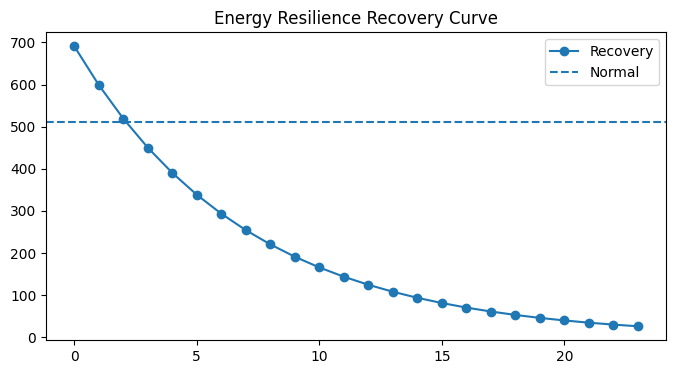

Resilience score: 2.653


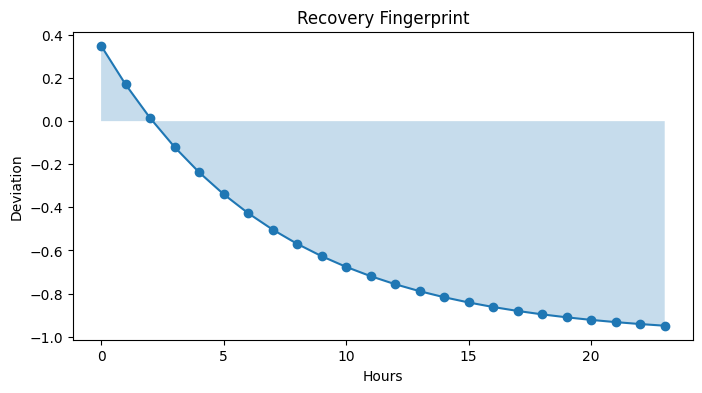

In [10]:
shock=base*1.35; recovery=shock*np.exp(-np.arange(24)/7)
score=1-(np.trapz(recovery-base)/24)/(base*.35)
fig,ax=plt.subplots(figsize=(8,4)); ax.plot(recovery,marker="o",label="Recovery"); ax.axhline(base,ls="--",label="Normal"); ax.set_title("Energy Resilience Recovery Curve"); ax.legend(); plt.show(); print("Resilience score:",round(float(score),3))

dev=(recovery-base)/base
fig,ax=plt.subplots(figsize=(8,4)); ax.fill_between(range(24),dev,0,alpha=.25); ax.plot(dev,marker="o"); ax.set_title("Recovery Fingerprint"); ax.set_xlabel("Hours"); ax.set_ylabel("Deviation"); plt.show()


# 11. Energy Risk Mapping & Future Energy Atlas
*One focused research purpose followed immediately by its executable analysis.*

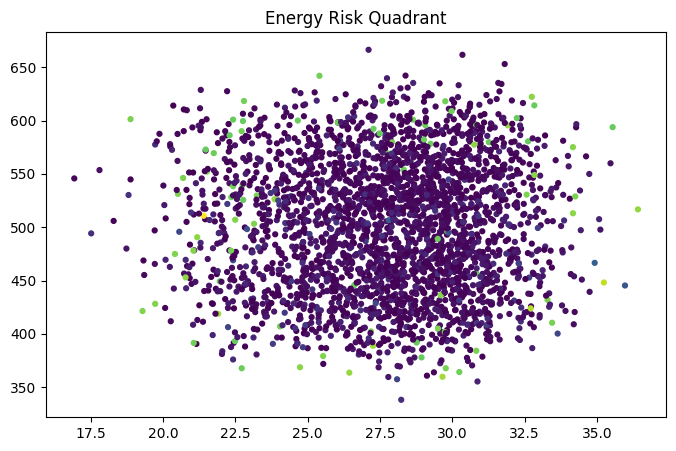

count    2880.000
mean       -0.466
std         0.195
min        -0.550
25%        -0.534
50%        -0.514
75%        -0.477
max         0.893
Name: risk, dtype: float64


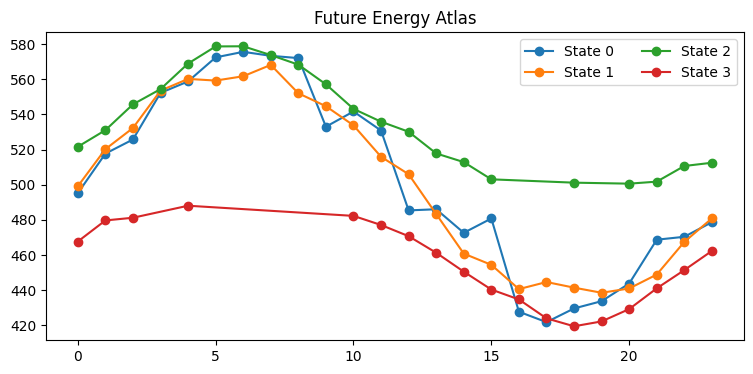

In [11]:
risk=dna.copy(); risk["risk"]=0.55*risk.unknown+0.45*(risk.conflict-risk.conflict.min())/(risk.conflict.max()-risk.conflict.min()+1e-9)
fig,ax=plt.subplots(figsize=(8,5)); ax.scatter(risk.temperature,risk.load,c=risk.risk,s=12); ax.set_title("Energy Risk Quadrant"); plt.show(); print(risk.risk.describe().round(3))

atlas=dna.groupby(["hour","state"],as_index=False).agg(load=("load","mean")) if "hour" in dna else dna.assign(hour=dna.timestamp.dt.hour).groupby(["hour","state"],as_index=False).agg(load=("load","mean"))
fig,ax=plt.subplots(figsize=(9,4));
for s,g in atlas.groupby("state"): ax.plot(g.hour,g.load,marker="o",label=f"State {s}")
ax.set_title("Future Energy Atlas"); ax.legend(ncol=2); plt.show()


# 12. Human-Centred Energy Forecasting
*One focused research purpose followed immediately by its executable analysis.*

                metric      value
       Latest forecast 511.856343
           Recent risk  -0.502450
Intervention potential  51.185634
         Recovery time   2.000000


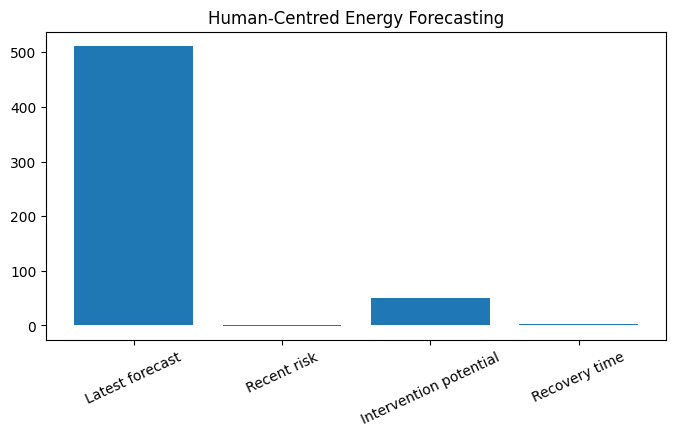

In [12]:
summary=pd.DataFrame({"metric":["Latest forecast","Recent risk","Intervention potential","Recovery time"],"value":[base,risk.risk.tail(24).mean(),base*.1,next((i for i,v in enumerate(recovery) if v<base*1.05),24)]})
print(summary.to_string(index=False))
fig,ax=plt.subplots(figsize=(8,4)); ax.bar(summary.metric,summary.value); ax.set_title("Human-Centred Energy Forecasting"); ax.tick_params(axis="x",rotation=25); plt.show()


# 13. Human-Centred Energy Forecasting
*One focused research purpose followed immediately by its executable analysis.*

                metric      value
       Latest forecast 511.856343
           Recent risk  -0.502450
Intervention potential  51.185634
         Recovery time   2.000000


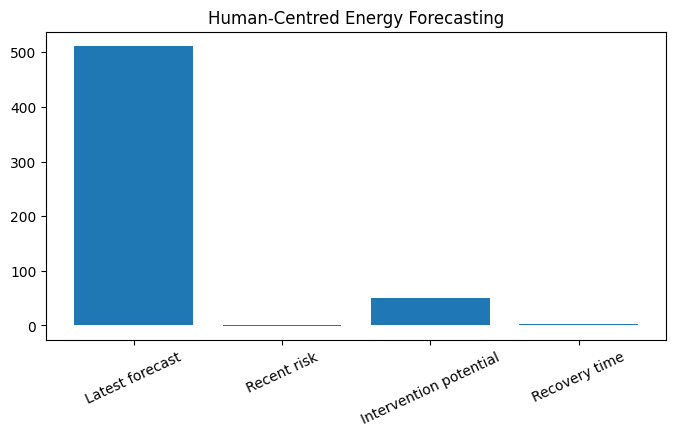

In [13]:
summary=pd.DataFrame({"metric":["Latest forecast","Recent risk","Intervention potential","Recovery time"],"value":[base,risk.risk.tail(24).mean(),base*.1,next((i for i,v in enumerate(recovery) if v<base*1.05),24)]})
print(summary.to_string(index=False))
fig,ax=plt.subplots(figsize=(8,4)); ax.bar(summary.metric,summary.value); ax.set_title("Human-Centred Energy Forecasting"); ax.tick_params(axis="x",rotation=25); plt.show()


# 14. Energy Copilot / Forecast Chatbot
*One focused research purpose followed immediately by its executable analysis.*

In [16]:
!pip -q install -U google-genai ipywidgets

import json, html, ipywidgets as widgets
from IPython.display import display, HTML, clear_output
from google import genai

GEMINI_API_KEY = "AQ.Ab8RN6JOdB3BjE3nAqOBWgdD30n_KiWPW-ZymgPuxXqd2kCi9Q"
client = genai.Client(api_key=GEMINI_API_KEY)

latest_forecast = float(te.forecast.iloc[-1])
forecast_peak = float(te.forecast.max())
recent_risk = float(risk.risk.tail(24).mean())
memory_lag = int(next((i for i,a in zip(lags,acf) if a < .5),72))
resilience_score = float(score)

ENERGY_CONTEXT = {
    "latest_forecast": latest_forecast,
    "forecast_peak": forecast_peak,
    "recent_risk": recent_risk,
    "hidden_state": int(dna.state.iloc[-1]),
    "resilience_score": resilience_score,
    "memory_lag_hours": memory_lag,
    "recent_temperature": float(dna.temperature.iloc[-1]),
    "recent_rain": float(dna.rain.iloc[-1]),
    "unknown_anomalies": int(len(u)),
    "tipping_candidates": int(len(tip)),
    "dataset": "mAIEnergy",
    "dataset_source": "Zenodo DOI 10.5281/zenodo.16401633"
}

chat_history = []

display(HTML("""
<style>
.ec{max-width:1050px;margin:12px auto;font-family:Arial,sans-serif;color:#e5e7eb;background:#0b1020;border:1px solid #26314d;border-radius:24px;overflow:hidden}
.eh{padding:22px 26px;background:linear-gradient(135deg,#111827,#172554,#1d4ed8);display:flex;gap:15px;align-items:center}
.logo{width:48px;height:48px;border-radius:15px;background:#ffffff20;display:flex;align-items:center;justify-content:center;font-size:25px}
.title{font-size:26px;font-weight:700}.sub{font-size:13px;color:#bfdbfe;margin-top:4px}
</style>
<div class="ec"><div class="eh"><div class="logo">⚡</div><div><div class="title">Energy Copilot</div><div class="sub">Multimodal Energy Intelligence • Forecast • Risk • What-If</div></div></div></div>
"""))

chat_box = widgets.Output(layout=widgets.Layout(height="400px",overflow_y="auto",width="100%",padding="12px"))
question = widgets.Textarea(placeholder="Ask anything about the energy system...",layout=widgets.Layout(width="78%",height="60px"))
send = widgets.Button(description="Send",icon="paper-plane",button_style="primary",layout=widgets.Layout(width="10%",height="60px"))
clear = widgets.Button(description="Clear",icon="trash",layout=widgets.Layout(width="10%",height="60px"))
status = widgets.HTML("<b style='color:green'>● Ready</b>")

def ask_ai(q):
    prompt=f"""You are Energy Copilot, an expert energy forecasting assistant.
Answer naturally and accurately. Use the actual notebook values below when relevant.
Do not invent measurements. Calculate requested what-if values when possible.
Distinguish modelled scenarios from proven causality.

NOTEBOOK DATA:
{json.dumps(ENERGY_CONTEXT,indent=2)}

USER QUESTION:
{q}

Give a specific, useful answer with concise reasoning."""
    try:
        r=client.models.generate_content(model="gemini-2.5-flash",contents=prompt)
        return r.text if getattr(r,"text",None) else "No response returned."
    except Exception as e:
        return f"Gemini error: {type(e).__name__}: {e}"

def render():
    with chat_box:
        clear_output(wait=True)
        if not chat_history:
            display(HTML("<div style='text-align:center;padding:70px;color:#94a3b8;font-size:18px'>⚡ <b>Ask your Energy Copilot anything</b><br><small>Forecasts, weather, risk, anomalies, interventions, scenarios and resilience.</small></div>"))
        for role,msg in chat_history:
            safe=html.escape(msg).replace("\n","<br>")
            if role=="user":
                display(HTML(f"<div style='background:#2563eb;color:white;padding:13px 16px;border-radius:16px;margin:10px 0 10px 15%'><b>You</b><br>{safe}</div>"))
            else:
                display(HTML(f"<div style='background:#111c32;color:#e5e7eb;border:1px solid #263657;padding:14px 16px;border-radius:16px;margin:10px 12% 10px 0'><b>⚡ Energy Copilot</b><br>{safe}</div>"))

def send_question(_):
    q=question.value.strip()
    if not q:return
    chat_history.append(("user",q))
    question.value=""
    status.value="<b style='color:#60a5fa'>● Thinking...</b>"
    render()
    chat_history.append(("assistant",ask_ai(q)))
    render()
    status.value="<b style='color:#4ade80'>● Ready</b>"

def clear_chat(_):
    chat_history.clear()
    render()
    status.value="<b style='color:#94a3b8'>● Chat cleared</b>"

send.on_click(send_question)
clear.on_click(clear_chat)
render()
display(chat_box)
display(widgets.HBox([question,send,clear]))
display(status)


Output(layout=Layout(height='400px', overflow_y='auto', padding='12px', width='100%'))

HTML(value="<b style='color:green'>● Ready</b>")

# 15. Energy Crisis & What-If Power BI Dashboard
*One focused research purpose followed immediately by its executable analysis.*

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import ipywidgets as widgets

reference=float(te.forecast.iloc[-1])
forecast_values=np.asarray(te.forecast.dropna(),dtype=float)

def dashboard_model(energy_change=0,weather_change=0,appliance_change=0,human_change=0):
    projected=reference*(1+energy_change/100)*(1+.35*weather_change/100)*(1+.55*appliance_change/100)*(1-.45*human_change/100)
    delta=projected-reference
    current_risk=float(risk.risk.tail(24).mean())
    risk_value=float(np.clip(current_risk+max(delta/max(reference,1),0)*.8,0,1))
    status="Critical" if projected>reference*1.25 else "High" if projected>reference*1.10 else "Moderate" if projected>reference*1.03 else "Stable"
    effects=np.array([reference*energy_change/100,reference*.35*weather_change/100,reference*.55*appliance_change/100,-reference*.45*human_change/100])
    return projected,delta,risk_value,status,effects

def show_dashboard(energy_change=0,weather_change=0,appliance_change=0,human_change=0):
    projected,delta,risk_value,status,effects=dashboard_model(energy_change,weather_change,appliance_change,human_change)
    factors=["Energy","Weather","Appliances","Human Behaviour"]
    hours=np.arange(24)
    baseline=np.resize(forecast_values,24)
    scenario=baseline*projected/max(reference,1)

    fig=plt.figure(figsize=(18,11))
    ax1=plt.subplot(2,3,1)
    ax1.bar(["Baseline","What-If"],[reference,projected])
    ax1.set_title("Demand Impact",fontweight="bold")
    for i,v in enumerate([reference,projected]):ax1.text(i,v,f"{v:.1f}",ha="center",va="bottom")

    ax2=plt.subplot(2,3,2)
    ax2.bar(factors,effects)
    ax2.axhline(0,ls="--")
    ax2.set_title("Driver Contribution",fontweight="bold")
    ax2.tick_params(axis="x",rotation=25)

    ax3=plt.subplot(2,3,3)
    pie=np.abs(effects) if np.abs(effects).sum()>0 else np.ones(4)
    ax3.pie(pie,labels=factors,autopct="%1.1f%%",startangle=90,wedgeprops={"width":.42})
    ax3.set_title("Energy Impact Distribution",fontweight="bold")

    ax4=plt.subplot(2,3,4)
    ax4.fill_between(hours,baseline,alpha=.22,label="Baseline")
    ax4.fill_between(hours,scenario,alpha=.22,label="What-If")
    ax4.plot(hours,baseline,lw=2,label="Baseline")
    ax4.plot(hours,scenario,lw=2,label="What-If")
    ax4.set_title("24-Hour Scenario Landscape",fontweight="bold")
    ax4.set_xlabel("Hour");ax4.set_ylabel("Load");ax4.legend()

    ax5=plt.subplot(2,3,5)
    shifted=forecast_values*projected/max(reference,1)
    ax5.hist(forecast_values,bins=25,alpha=.5,label="Baseline")
    ax5.hist(shifted,bins=25,alpha=.5,label="What-If")
    ax5.axvline(reference,ls="--",lw=2,label="Baseline")
    ax5.axvline(projected,ls="--",lw=2,label="What-If")
    ax5.set_title("Forecast Distribution",fontweight="bold")
    ax5.set_xlabel("Load");ax5.set_ylabel("Frequency");ax5.legend()

    ax6=plt.subplot(2,3,6)
    current=float(risk.risk.tail(24).mean())
    ax6.bar(["Current Risk","What-If Risk"],[current,risk_value])
    ax6.set_ylim(0,1)
    ax6.set_title(f"Risk Dashboard: {status}",fontweight="bold")
    for i,v in enumerate([current,risk_value]):ax6.text(i,v+.03,f"{v:.2f}",ha="center")

    plt.suptitle("POWER BI-STYLE ENERGY INTERVIEW DASHBOARD",fontsize=18,fontweight="bold")
    plt.tight_layout()
    plt.show()

    print("="*72)
    print("FINAL INTERVIEW ANSWER")
    print("="*72)
    print(f"Baseline Forecast      : {reference:.2f} load units")
    print(f"What-If Forecast       : {projected:.2f} load units")
    print(f"Demand Change          : {delta:+.2f} load units")
    print(f"Percentage Change      : {delta/max(reference,1)*100:+.2f}%")
    print(f"Risk Score             : {risk_value:.2f}")
    print(f"Risk Status             : {status}")
    print(f"Energy Effect           : {effects[0]:+.2f}")
    print(f"Weather Effect          : {effects[1]:+.2f}")
    print(f"Appliance Effect        : {effects[2]:+.2f}")
    print(f"Human Behaviour Effect  : {effects[3]:+.2f}")
    print("Interpretation: these are modelled scenario effects, not guaranteed causal relationships.")

controls={
    "energy_change":widgets.IntSlider(description="Energy %",min=-30,max=50,value=0,continuous_update=True),
    "weather_change":widgets.IntSlider(description="Weather %",min=-30,max=80,value=0,continuous_update=True),
    "appliance_change":widgets.IntSlider(description="Appliances %",min=-30,max=80,value=0,continuous_update=True),
    "human_change":widgets.IntSlider(description="Efficiency %",min=0,max=50,value=0,continuous_update=True)
}
display(widgets.HTML("<h2>⚡ Future Energy Crisis & What-If Simulator</h2><p>Move any slider and every chart updates immediately.</p>"))
display(widgets.VBox(list(controls.values())))
display(widgets.interactive_output(show_dashboard,controls))


HTML(value='<h2>⚡ Future Energy Crisis & What-If Simulator</h2><p>Move any slider and every chart updates imme…

Output()